# Financial markets & returns

*The starting point for everything else in this collection.*

Before any model, three ideas have to be second nature: what is **traded**, how
we turn a price series into **returns**, and what those returns actually **look
like**. Get these right and the rest of quantitative finance is built on solid
ground.

**Instruments.** A *price* $P_t$ is the going rate for one unit of an asset —
a share/ETF (equity), a bond (a stream of fixed cashflows), an option (the right
to trade later), an FX pair, a futures contract. Different payoffs, but they all
produce a price series, and we model the *returns* of that series.

**Roadmap**

1. From prices to returns — simple vs **log** returns, and why log wins
2. Compounding and **annualisation** — the $\sqrt{T}$ rule for risk
3. The empirical shape of returns — **fat tails** and **volatility clustering**
4. Risk & reward — cumulative wealth, drawdown, the Sharpe ratio
5. Assets in risk/return space


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# qufin gives you these return/risk tools out of the box (used below):
from qufin.portfolio import annualized_volatility, sharpe_ratio, max_drawdown
from qufin.timeseries import acf

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. From prices to returns

We almost never model prices directly — they are non-stationary (they wander and
trend). We model **returns**, which are roughly stationary and comparable across
assets and time. Two definitions:

* **Simple (arithmetic) return:** $\;R_t = \dfrac{P_t}{P_{t-1}} - 1$
* **Log (continuously-compounded) return:** $\;r_t = \ln\dfrac{P_t}{P_{t-1}}$

For small moves they are nearly identical ($r \approx R$), but **log returns are
additive across time** — the multi-period log return is just the *sum* of the
single-period ones — which is exactly what makes them the natural modelling unit.


In [2]:
def load_prices(ticker='SPY', start='2005-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        s = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        s = s['Close'].dropna().to_numpy(dtype='float64').ravel()
        if len(s) > 1000:
            return s
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic prices')
    rng = np.random.default_rng(0)
    return 100.0 * np.exp(np.cumsum(rng.normal(0.0003, 0.011, 5000)))

px = load_prices()
simple = px[1:] / px[:-1] - 1.0
logret = np.diff(np.log(px))

print(f'{len(px)} prices, {px[0]:.1f} -> {px[-1]:.1f}')
print(f'simple vs log on a calm day:  R={simple[10]:+.5f}  r={logret[10]:+.5f}  (nearly equal)')
big = int(np.argmax(np.abs(simple)))
print(f'on the biggest move:          R={simple[big]:+.4f}  r={logret[big]:+.4f}  (they diverge)')

# Additivity: the total log return equals the sum of daily log returns exactly.
total_log = np.log(px[-1] / px[0])
print(f'\nsum of daily log returns = {logret.sum():.4f}   ln(P_T/P_0) = {total_log:.4f}  (identical)')
print(f'product of (1+simple)-1   = {np.prod(1 + simple) - 1:.4f}   '
      f'P_T/P_0 - 1 = {px[-1]/px[0] - 1:.4f}  (simple returns COMPOUND, not add)')


5032 prices, 81.4 -> 579.8
simple vs log on a calm day:  R=-0.01046  r=-0.01052  (nearly equal)
on the biggest move:          R=+0.1452  r=+0.1356  (they diverge)

sum of daily log returns = 1.9635   ln(P_T/P_0) = 1.9635  (identical)
product of (1+simple)-1   = 6.1244   P_T/P_0 - 1 = 6.1244  (simple returns COMPOUND, not add)


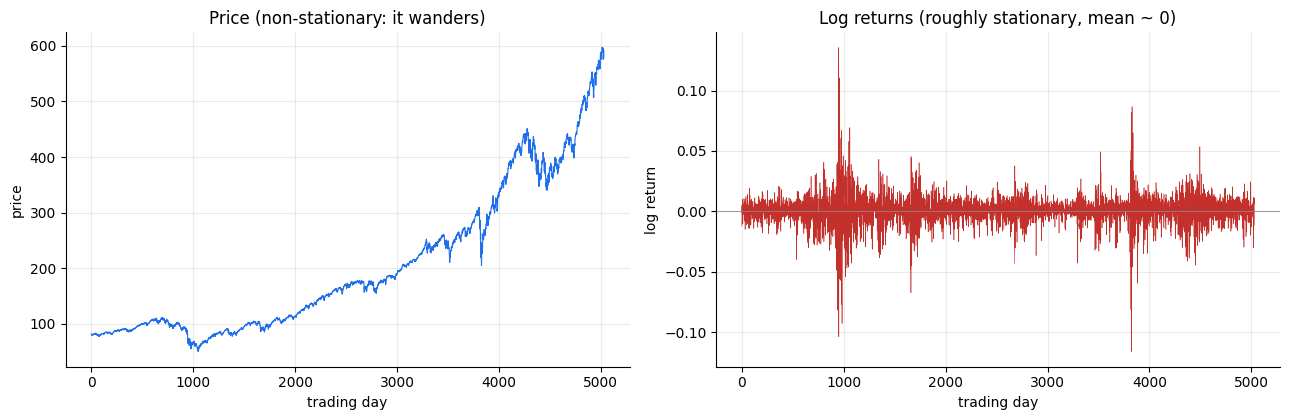

In [3]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(13, 4.3))
axl.plot(px, color='#1f6feb', lw=0.8); axl.set_title('Price (non-stationary: it wanders)')
axl.set_xlabel('trading day'); axl.set_ylabel('price')
axr.plot(logret, color='#c4302b', lw=0.4); axr.axhline(0, color='#888', lw=0.6)
axr.set_title('Log returns (roughly stationary, mean ~ 0)')
axr.set_xlabel('trading day'); axr.set_ylabel('log return')
plt.tight_layout(); plt.show()


## 2. Compounding and annualisation

To compare a daily number with a yearly one we **annualise**. Under the common
i.i.d. assumption:

* **Return** compounds: $\;(1+\bar R)^{252}-1$ (geometric), and the *geometric*
  mean is always $\le$ the arithmetic mean — volatility is a drag on compounding.
* **Volatility** scales with the square root of time: $\;\sigma_{\text{ann}} =
  \sigma_{\text{daily}}\sqrt{252}$. This $\sqrt{T}$ rule is everywhere in finance
  (option pricing, VaR, vol targeting).


daily: arithmetic mean=+0.00046  vol=0.01200
annualised return  arithmetic=+11.7%   geometric=+10.3%  (geometric < arithmetic: the variance drag)
drag ~ 0.5*sigma^2_ann = 1.8%   (observed gap = 1.3%)
annualised vol = daily_vol * sqrt(252) = 19.1%
qufin.portfolio.annualized_volatility = 19.0%


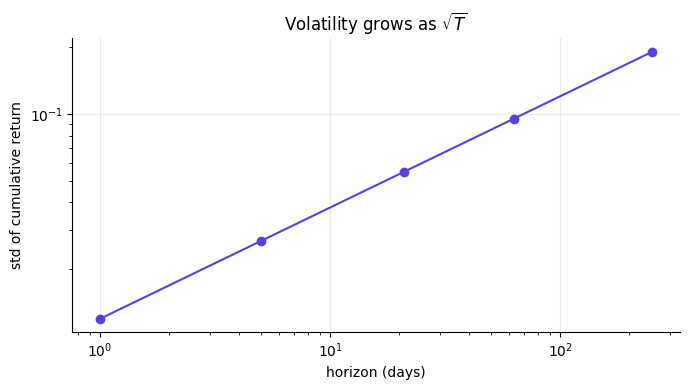

In [4]:
arith_daily = float(simple.mean())          # arithmetic mean of SIMPLE returns
daily_vol = logret.std()
arith_ann = arith_daily * 252               # arithmetic annualisation
geom_ann = np.prod(1 + simple) ** (252 / len(simple)) - 1   # geometric (compound)
print(f'daily: arithmetic mean={arith_daily:+.5f}  vol={daily_vol:.5f}')
print(f'annualised return  arithmetic={arith_ann:+.1%}   geometric={geom_ann:+.1%}  '
      '(geometric < arithmetic: the variance drag)')
print(f'drag ~ 0.5*sigma^2_ann = {0.5 * daily_vol**2 * 252:.1%}   '
      f'(observed gap = {arith_ann - geom_ann:.1%})')
print(f'annualised vol = daily_vol * sqrt(252) = {daily_vol * np.sqrt(252):.1%}')
print(f'qufin.portfolio.annualized_volatility = {annualized_volatility(simple):.1%}')

horizons = np.array([1, 5, 21, 63, 252])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(horizons, daily_vol * np.sqrt(horizons), 'o-', color='#5b3fd8')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Volatility grows as $\\sqrt{T}$'); ax.set_xlabel('horizon (days)')
ax.set_ylabel('std of cumulative return')
plt.tight_layout(); plt.show()


## 3. The shape of returns — fat tails & clustering

Returns are **not** Gaussian. Two stylised facts dominate every market:

* **Fat tails (leptokurtosis).** Extreme moves happen far more often than a
  normal distribution predicts — the kurtosis is well above 3. The QQ-plot bends
  away from the line at both ends.
* **Volatility clustering.** Returns themselves are nearly uncorrelated, but
  their *magnitudes* are strongly autocorrelated — calm follows calm, storms
  follow storms. This is the empirical fact the **GARCH** models (notebook 15)
  are built to capture.


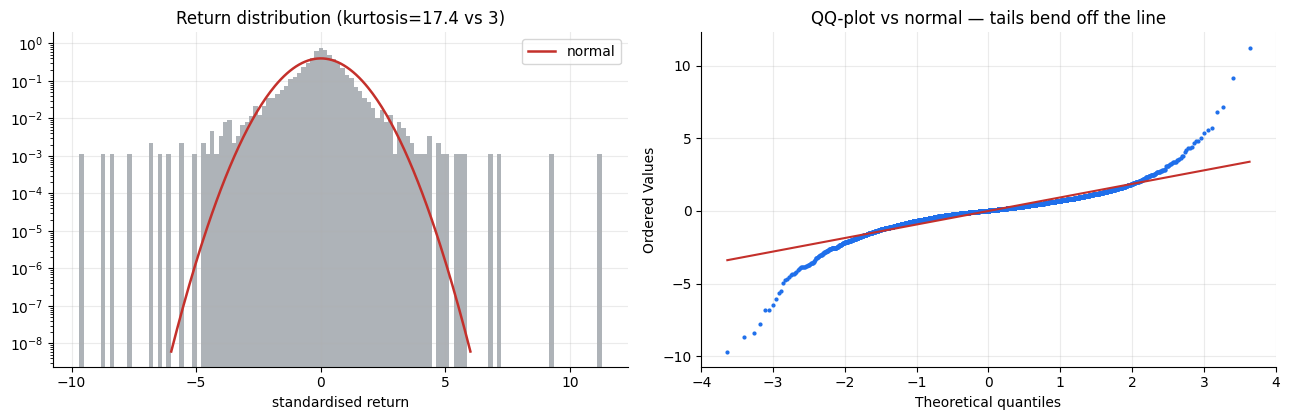

days beyond +/-3 sigma: observed 1.69%  vs normal 0.27%


In [5]:
z = (logret - logret.mean()) / logret.std()
kurt = float(np.mean(z**4))          # 3 for a normal
fig, (axh, axq) = plt.subplots(1, 2, figsize=(13, 4.3))
axh.hist(z, bins=120, density=True, color='#9aa0a6', alpha=0.8)
grid = np.linspace(-6, 6, 200)
axh.plot(grid, stats.norm.pdf(grid), color='#c4302b', lw=1.8, label='normal')
axh.set_yscale('log'); axh.set_title(f'Return distribution (kurtosis={kurt:.1f} vs 3)')
axh.set_xlabel('standardised return'); axh.legend()
stats.probplot(z, dist='norm', plot=axq)
axq.get_lines()[0].set(color='#1f6feb', ms=2); axq.get_lines()[1].set(color='#c4302b')
axq.set_title('QQ-plot vs normal — tails bend off the line')
plt.tight_layout(); plt.show()
print(f'days beyond +/-3 sigma: observed {np.mean(np.abs(z) > 3):.2%}  '
      f'vs normal {2 * stats.norm.sf(3):.2%}')


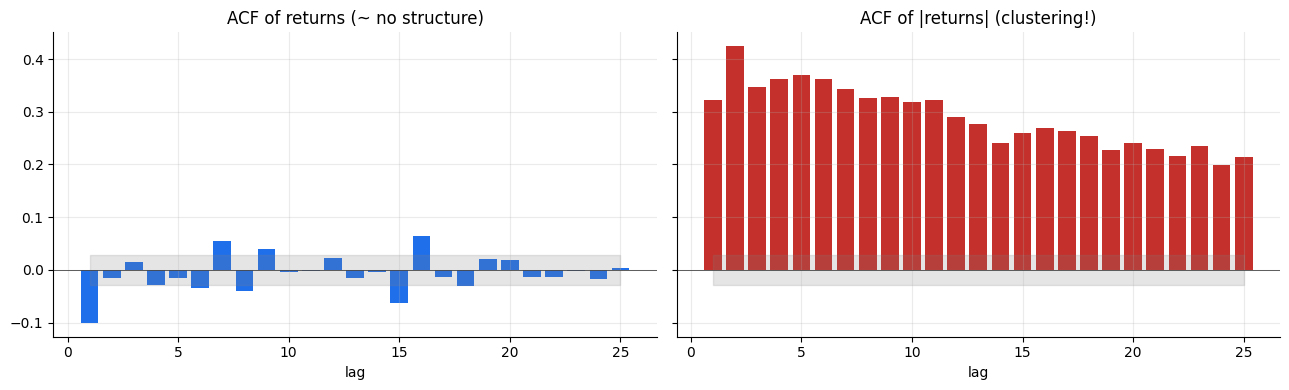

In [6]:
ac_r = acf(logret, nlags=25)
ac_abs = acf(np.abs(logret), nlags=25)
lags = np.arange(1, 26)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
a1.bar(lags, ac_r.values, color='#1f6feb'); a1.axhline(0, color='#444', lw=0.6)
a1.fill_between(lags, ac_r.lower_ci, ac_r.upper_ci, color='gray', alpha=0.2)
a1.set_title('ACF of returns (~ no structure)'); a1.set_xlabel('lag')
a2.bar(lags, ac_abs.values, color='#c4302b'); a2.axhline(0, color='#444', lw=0.6)
a2.fill_between(lags, ac_abs.lower_ci, ac_abs.upper_ci, color='gray', alpha=0.2)
a2.set_title('ACF of |returns| (clustering!)'); a2.set_xlabel('lag')
plt.tight_layout(); plt.show()


## 4. Risk & reward

Two numbers summarise an equity curve:

* **Maximum drawdown** — the worst peak-to-trough loss; the pain an investor
  actually lives through.
* **Sharpe ratio** — annualised excess return per unit of volatility; the
  standard risk-adjusted score. (Beware: it punishes upside and downside equally
  and assumes roughly Gaussian returns — fat tails make a high Sharpe less safe
  than it looks.)


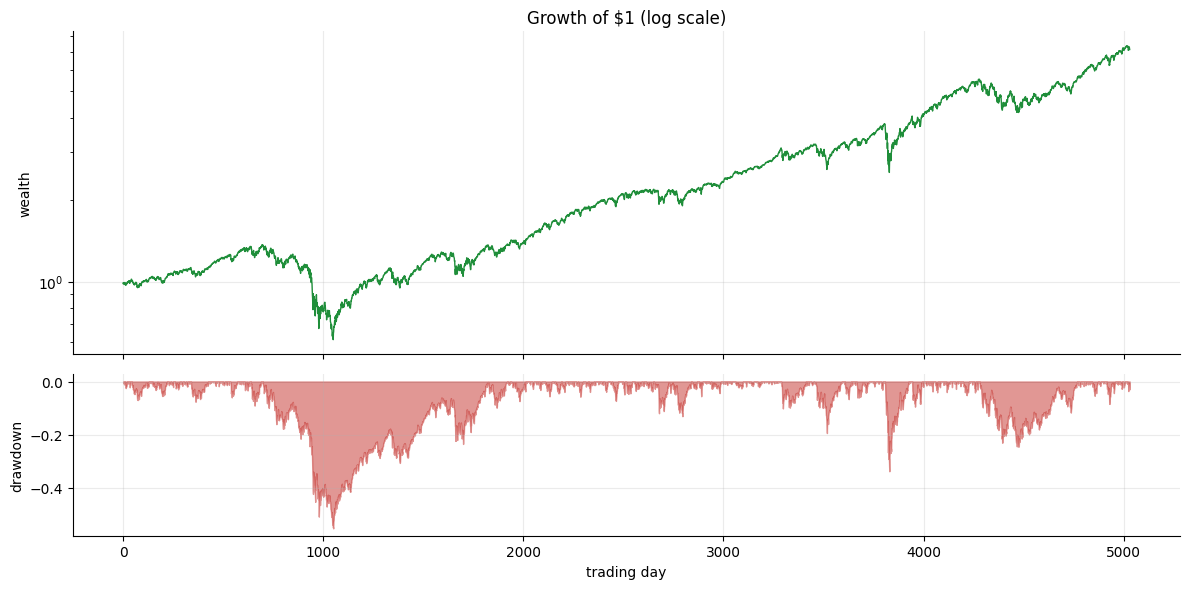

Sharpe (rf=0)   = 0.61
max drawdown    = 55.2%
ann. volatility = 19.0%


In [7]:
wealth = np.cumprod(1 + simple)
peak = np.maximum.accumulate(wealth)
dd = wealth / peak - 1.0
fig, (axw, axd) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1], figsize=(12, 6))
axw.plot(wealth, color='#1f8e3a', lw=1.0); axw.set_yscale('log')
axw.set_title('Growth of $1 (log scale)'); axw.set_ylabel('wealth')
axd.fill_between(np.arange(len(dd)), dd, color='#c4302b', alpha=0.5)
axd.set_ylabel('drawdown'); axd.set_xlabel('trading day')
plt.tight_layout(); plt.show()
print(f'Sharpe (rf=0)   = {sharpe_ratio(simple):.2f}')
print(f'max drawdown    = {max_drawdown(simple):.1%}')
print(f'ann. volatility = {annualized_volatility(simple):.1%}')


## 5. Assets in risk/return space

Every asset is a point in (risk, reward) space. Higher expected return generally
demands higher volatility — but the relationship is noisy, and *combining* assets
(notebook 24, portfolio optimization) can improve the trade-off through
diversification.


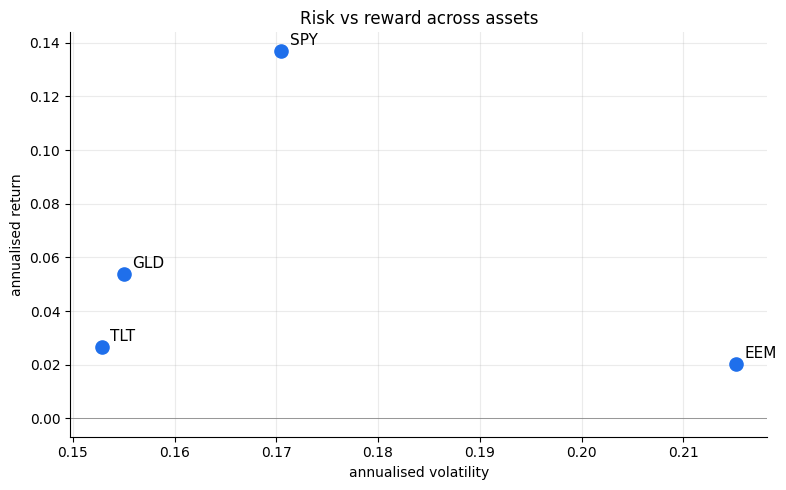

In [8]:
def load_multi(tickers=('SPY', 'TLT', 'GLD', 'EEM'), start='2010-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        raw = yf.download(list(tickers), start=start, end=end, auto_adjust=True, progress=False)
        close = raw['Close'][list(tickers)].dropna()
        if len(close) > 800:
            return close.to_numpy(dtype='float64'), list(close.columns)
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic')
    rng = np.random.default_rng(3); n = 3000
    mus = [0.0004, 0.0002, 0.0003, 0.0004]; vols = [0.011, 0.009, 0.010, 0.016]
    cols = [100 * np.exp(np.cumsum(rng.normal(m, v, n))) for m, v in zip(mus, vols)]
    return np.column_stack(cols), list(tickers)

panel, names = load_multi()
r = panel[1:] / panel[:-1] - 1.0
ann_ret = np.array([np.prod(1 + r[:, j]) ** (252 / len(r)) - 1 for j in range(len(names))])
ann_vol = r.std(axis=0) * np.sqrt(252)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ann_vol, ann_ret, s=90, color='#1f6feb', zorder=3)
for i, n_ in enumerate(names):
    ax.annotate(n_, (ann_vol[i], ann_ret[i]), xytext=(6, 4), textcoords='offset points', fontsize=11)
ax.axhline(0, color='#888', lw=0.6)
ax.set_xlabel('annualised volatility'); ax.set_ylabel('annualised return')
ax.set_title('Risk vs reward across assets')
plt.tight_layout(); plt.show()


## What next?

* **Probability & statistics (notebook 02)** formalises the distributions and
  estimators we eyeballed here.
* **Stochastic processes (notebook 08)** gives the continuous-time models
  (Brownian motion, GBM) behind price dynamics.
* **GARCH (notebook 15)** turns "volatility clustering" into a forecasting model.
* **Portfolio optimization (notebook 24)** combines these risk/return points into
  an efficient book.
